In [1]:
import xgi
import numpy as np
from tqdm import tqdm
from had_model import HAD_model
from hypergraph_null_models import edge_shuffled_hypergraph
import matplotlib.pyplot as plt

# Generate or upload a hypergraph

#### Generate a random hypergraph

In [4]:
N = 300

#ps = [1e-3, 1e-4, 1e-6]
#H = xgi.fast_random_hypergraph(N, ps, seed=0)
#tag = f'Random_N_{N}_M_{len(ps)+1}'  # to fix for saving plots!

M = 3
k_avg = 10
H = xgi.uniform_erdos_renyi_hypergraph(N, M, k_avg, p_type="degree")
tag = f'ER{M}_{N}_{k_avg}'   # to fix for saving plots!

H.cleanup()

print(H, '\nHyperedge sizes:', xgi.unique_edge_sizes(H), '\nConnected:',  xgi.is_connected(H))

Unnamed Hypergraph with 300 nodes and 1026 hyperedges 
Hyperedge sizes: [3] 
Connected: True


#### Or upload a real-world structure

In [7]:
tag = 'Thiers13'
with open(f'../data/SocioPatterns/aggr_15min_cliques_thr1_{tag}.json') as file: 
            data = json.load(file)
H = xgi.from_hyperedge_list(data)
# relabel and remove eventual multiple edges
H.cleanup(isolates=True, singletons=True, connected=False)

# Pairwise projections
G = xgi.to_graph(H)
H = xgi.Hypergraph(list(G.edges))
tag = f'proj_{tag}'

# ER reshuffled hypergraph
#H = edge_shuffled_hypergraph(H, seed=0)
#tag = f'Shuf_{tag}'

N = len(H.nodes)
print(H, '\nHyperedge sizes:', xgi.unique_edge_sizes(H), '\nConnected:',  xgi.is_connected(H))

Unnamed Hypergraph with 327 nodes and 5818 hyperedges 
Hyperedge sizes: [2] 
Connected: True


# Measure some observables as a function of $\epsilon$

In [10]:
groups_0 = H.edges.members()
sizes_0 = [len(e) for e in groups_0]

epsilons = np.linspace(0., 0.6, num=11)[1:]
params = ['max_min', 0.5, True, 'random']

groups_end = []

for eps in tqdm(epsilons): 
    Model = HAD_model(eps, groups_0)
    results = Model.simulate(condition=params[0], mu=params[1], split_overlap=params[2], split_seed=params[3])
    groups = results['groups']
    groups_end.append( [len(e) for e in groups[-1]] )

groups_end.append(sizes_0)

100%|███████████████████████████████████████████| 10/10 [00:07<00:00,  1.40it/s]


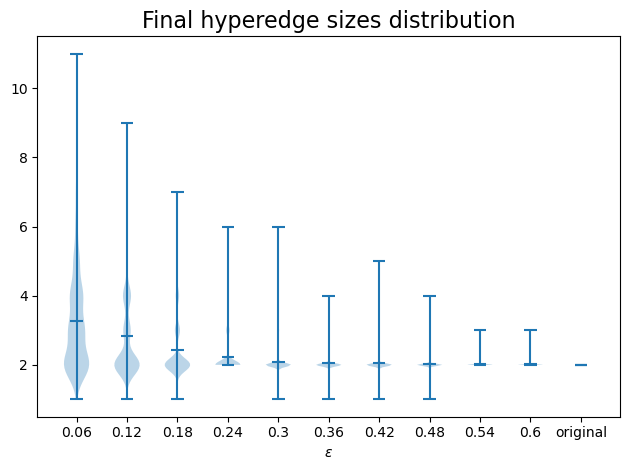

In [14]:
# plot results and save figure
plt.violinplot(groups_end, positions=range(len(groups_end)), showmeans=True)
labels = [str(ep) for ep in epsilons] + ['original']
plt.xticks(range(len(epsilons)+1), labels)
plt.xlabel(r'$\epsilon$')
plt.title('Final hyperedge sizes distribution', fontsize=16)

plt.tight_layout()
plt.savefig(f'../figures/Old_results_05_05_2025/{tag}/violin_{tag}_{params[0]}_{params[1]}_{params[2]}_{params[3]}.jpg')
plt.show()